In [1]:
# ============================================================
# ETP Market Making — Module 2: Delta Hedging
# Context: MM hedging cost on 3BRL during Brent stress
# Calibrated on: 23 March 2026 (Trump/Iran spike)
# ============================================================

import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import warnings
warnings.filterwarnings('ignore')

plt.style.use('dark_background')
plt.rcParams.update({
    'font.family': 'monospace',
    'axes.facecolor':  '#0d1117',
    'figure.facecolor': '#0d1117',
    'axes.edgecolor': '#30363d',
    'axes.labelcolor': '#8b949e',
    'xtick.color': '#8b949e',
    'ytick.color': '#8b949e',
    'grid.color': '#21262d',
    'grid.linewidth': 0.5,
    'text.color': '#e6edf3'
})

print("✓ Libraries loaded")

✓ Libraries loaded


In [2]:
# ============================================================
# DATA + DELTA HEDGING PARAMETERS
# ============================================================

ticker = yf.Ticker("BZ=F")
df = ticker.history(period="1d", interval="1m")

# Clean
df.index = df.index.tz_convert("Europe/London")
df = df[["Open", "High", "Low", "Close", "Volume"]].copy()
df.columns = df.columns.str.lower()

# Core parameters
OPEN_PRICE = df['close'].iloc[0]
LEVERAGE = 3
AUM = 10_000_000          # hypothetical MM exposure in USD
TICK_SIZE = 0.01          # Brent futures tick
CONTRACT_SIZE = 1000      # barrels per futures contract

# Log returns and vol
df['log_ret'] = np.log(df['close'] / df['close'].shift(1))
ANN_FACTOR = np.sqrt(252 * 390)
df['rvol'] = df['log_ret'].rolling(20).std() * ANN_FACTOR * 100
df['rvol_clean'] = df['rvol'].clip(upper=300)

# Drawdown from open
df['drawdown'] = (df['close'] / OPEN_PRICE - 1) * 100

# ── DELTA HEDGING MECHANICS ──
# MM is short delta on 3BRL (sold ETP to clients, must hedge with futures)
# Delta of 3BRL = 3 × notional / underlying price
# Number of contracts to hedge = (AUM × leverage) / (contract_size × spot)

df['delta'] = (AUM * LEVERAGE) / (CONTRACT_SIZE * df['close'])

# Delta change each bar — how many contracts MM must buy/sell to rebalance
df['delta_change'] = df['delta'].diff().abs()

# Hedging cost per bar = delta_change × spread on futures
# Futures bid-ask spread widens with vol: base 1 tick, up to 5 ticks in stress
df['futures_spread_ticks'] = (1 + 4 * (df['rvol_clean'] / 300)).clip(lower=1, upper=5)
df['futures_spread_usd'] = df['futures_spread_ticks'] * TICK_SIZE * CONTRACT_SIZE

# Cost per rebalance = delta_change × futures spread
df['hedge_cost_usd'] = df['delta_change'] * df['futures_spread_usd']
df['hedge_cost_bps'] = (df['hedge_cost_usd'] / AUM) * 10000

# Cumulative hedging cost
df['cum_hedge_cost_bps'] = df['hedge_cost_bps'].cumsum()

# Gamma P&L — MM is short gamma on leveraged ETP
# Short gamma = lose money when underlying moves a lot
# Approx gamma loss = 0.5 × gamma × (return)^2 × notional
df['gamma_loss_bps'] = 0.5 * LEVERAGE * (df['log_ret'] ** 2) * 10000

# Cumulative gamma loss
df['cum_gamma_loss_bps'] = df['gamma_loss_bps'].cumsum()

vol_at_spike = df.loc[df['close'].idxmin(), 'rvol_clean']
total_hedge_cost = df['hedge_cost_bps'].sum()
total_gamma_loss = df['gamma_loss_bps'].sum()

print(f"✓ Open:                  ${OPEN_PRICE:.2f}")
print(f"✓ AUM exposure:          ${AUM:,.0f}")
print(f"✓ Delta at open:         {df['delta'].iloc[0]:.1f} contracts")
print(f"✓ Delta at low:          {df['delta'].max():.1f} contracts")
print(f"✓ Vol at spike:          {vol_at_spike:.0f}% ann.")
print(f"✓ Max futures spread:    {df['futures_spread_ticks'].max():.1f} ticks")
print(f"✓ Total hedge cost:      {total_hedge_cost:.1f} bps")
print(f"✓ Total gamma loss:      {total_gamma_loss:.1f} bps")
print(f"✓ Total MM cost:         {total_hedge_cost + total_gamma_loss:.1f} bps")

✓ Open:                  $107.92
✓ AUM exposure:          $10,000,000
✓ Delta at open:         278.0 contracts
✓ Delta at low:          320.4 contracts
✓ Vol at spike:          300% ann.
✓ Max futures spread:    5.0 ticks
✓ Total hedge cost:      11.4 bps
✓ Total gamma loss:      190.1 bps
✓ Total MM cost:         201.5 bps


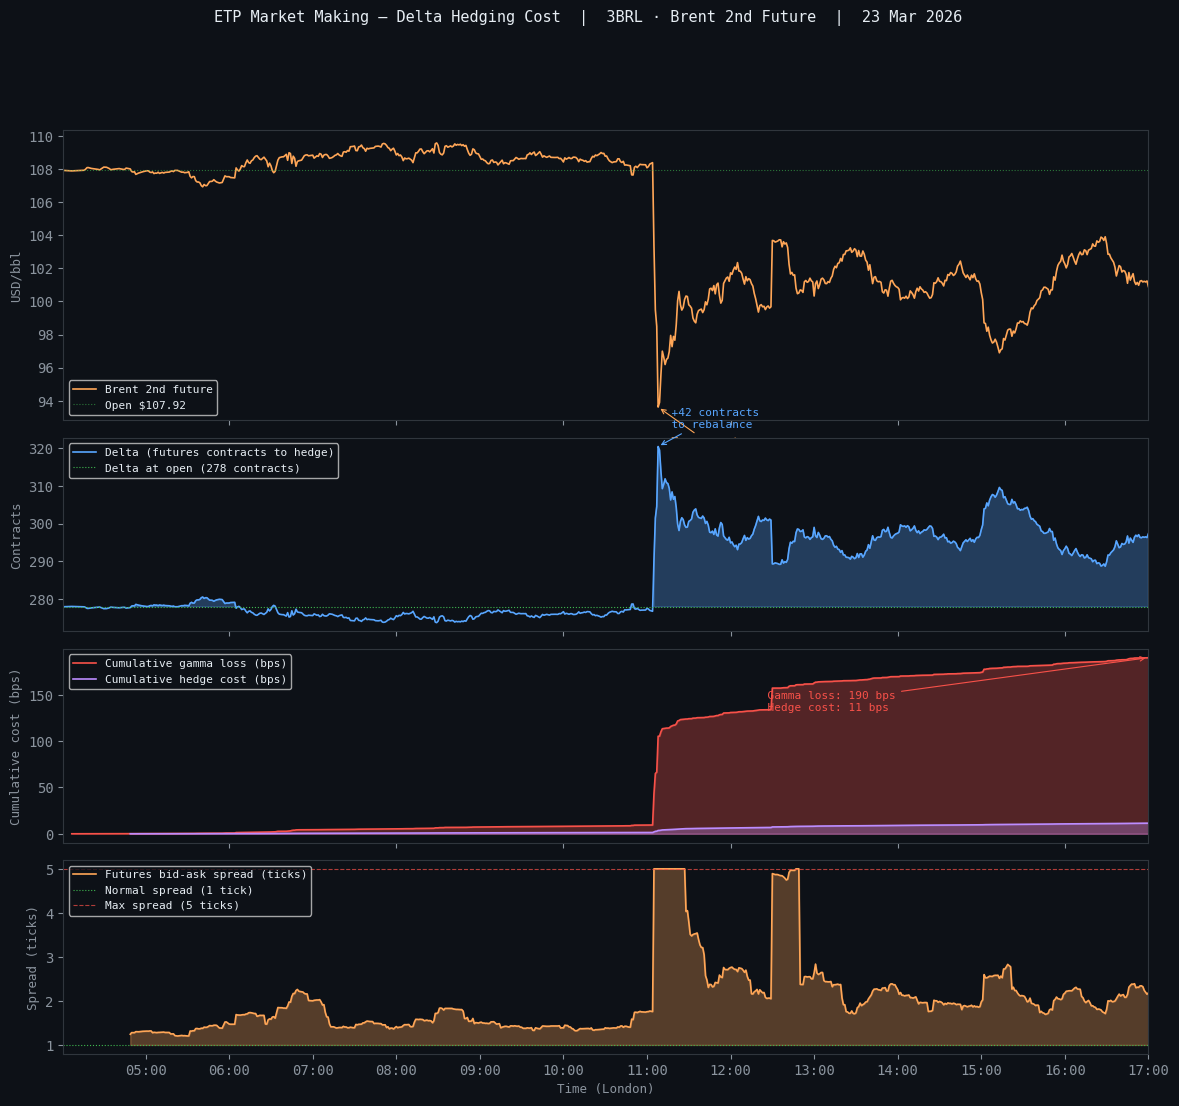

✓ Chart saved → assets/delta_hedging.png


In [3]:
# ============================================================
# PLOT — Delta Hedging Dashboard
# ============================================================

fig = plt.figure(figsize=(14, 12))
fig.suptitle(
    "ETP Market Making — Delta Hedging Cost  |  3BRL · Brent 2nd Future  |  23 Mar 2026",
    fontsize=11, color='#e6edf3', y=0.98
)

gs = gridspec.GridSpec(4, 1, hspace=0.08, height_ratios=[3, 2, 2, 2])

low_idx = df['close'].idxmin()

# --- Panel 1: Brent price ---
ax1 = fig.add_subplot(gs[0])
ax1.plot(df.index, df['close'], color='#ffa657', linewidth=1.2,
         label='Brent 2nd future')
ax1.axhline(OPEN_PRICE, color='#3fb950', linewidth=0.8,
            linestyle=':', alpha=0.6, label=f'Open ${OPEN_PRICE:.2f}')
ax1.annotate(
    f"  Trump post\n  ${df['close'].min():.2f} ({df['drawdown'].min():.1f}%)",
    xy=(low_idx, df['close'].min()),
    xytext=(low_idx, df['close'].min() - 3),
    color='#ffa657', fontsize=8,
    arrowprops=dict(arrowstyle='->', color='#ffa657', lw=0.8)
)
ax1.set_ylabel('USD/bbl', fontsize=9)
ax1.legend(fontsize=8, loc='lower left')
ax1.set_xticklabels([])
ax1.set_xlim(df.index[0], df.index[-1])

# --- Panel 2: Delta (number of contracts) ---
ax2 = fig.add_subplot(gs[1])
ax2.fill_between(df.index, df['delta'], df['delta'].iloc[0],
                 where=df['delta'] > df['delta'].iloc[0],
                 color='#58a6ff', alpha=0.3)
ax2.plot(df.index, df['delta'], color='#58a6ff', linewidth=1.2,
         label='Delta (futures contracts to hedge)')
ax2.axhline(df['delta'].iloc[0], color='#3fb950', linewidth=0.8,
            linestyle=':', label=f'Delta at open ({df["delta"].iloc[0]:.0f} contracts)')
ax2.annotate(
    f"  +{df['delta'].max() - df['delta'].iloc[0]:.0f} contracts\n  to rebalance",
    xy=(low_idx, df['delta'].max()),
    xytext=(low_idx, df['delta'].max() + 5),
    color='#58a6ff', fontsize=8,
    arrowprops=dict(arrowstyle='->', color='#58a6ff', lw=0.8)
)
ax2.set_ylabel('Contracts', fontsize=9)
ax2.legend(fontsize=8, loc='upper left')
ax2.set_xticklabels([])
ax2.set_xlim(df.index[0], df.index[-1])

# --- Panel 3: Cumulative gamma loss vs hedge cost ---
ax3 = fig.add_subplot(gs[2])
ax3.fill_between(df.index, df['cum_gamma_loss_bps'],
                 color='#f85149', alpha=0.3)
ax3.plot(df.index, df['cum_gamma_loss_bps'], color='#f85149',
         linewidth=1.2, label='Cumulative gamma loss (bps)')
ax3.fill_between(df.index, df['cum_hedge_cost_bps'],
                 color='#bc8cff', alpha=0.3)
ax3.plot(df.index, df['cum_hedge_cost_bps'], color='#bc8cff',
         linewidth=1.2, label='Cumulative hedge cost (bps)')
ax3.annotate(
    f"  Gamma loss: {total_gamma_loss:.0f} bps\n  Hedge cost: {total_hedge_cost:.0f} bps",
    xy=(df.index[-1], df['cum_gamma_loss_bps'].iloc[-1]),
    xytext=(df.index[int(len(df)*0.6)], df['cum_gamma_loss_bps'].max() * 0.7),
    color='#f85149', fontsize=8,
    arrowprops=dict(arrowstyle='->', color='#f85149', lw=0.8)
)
ax3.set_ylabel('Cumulative cost (bps)', fontsize=9)
ax3.legend(fontsize=8, loc='upper left')
ax3.set_xticklabels([])
ax3.set_xlim(df.index[0], df.index[-1])

# --- Panel 4: Futures spread ticks ---
ax4 = fig.add_subplot(gs[3])
ax4.fill_between(df.index, df['futures_spread_ticks'], 1,
                 where=df['futures_spread_ticks'] > 1,
                 color='#ffa657', alpha=0.3)
ax4.plot(df.index, df['futures_spread_ticks'], color='#ffa657',
         linewidth=1.2, label='Futures bid-ask spread (ticks)')
ax4.axhline(1, color='#3fb950', linewidth=0.8,
            linestyle=':', label='Normal spread (1 tick)')
ax4.axhline(5, color='#f85149', linewidth=0.8,
            linestyle='--', alpha=0.7, label='Max spread (5 ticks)')
ax4.set_ylabel('Spread (ticks)', fontsize=9)
ax4.set_xlabel('Time (London)', fontsize=9)
ax4.legend(fontsize=8, loc='upper left')
ax4.set_xlim(df.index[0], df.index[-1])

import matplotlib.dates as mdates
ax4.xaxis.set_major_formatter(mdates.DateFormatter('%H:%M'))
ax4.xaxis.set_major_locator(mdates.HourLocator())

plt.savefig('../assets/delta_hedging.png', dpi=150,
            bbox_inches='tight', facecolor='#0d1117')
plt.savefig('delta_hedging.png', dpi=150,
            bbox_inches='tight', facecolor='#0d1117')
plt.show()
print("✓ Chart saved → assets/delta_hedging.png")

In [4]:
# ============================================================
# SUMMARY STATS
# ============================================================

print("=" * 52)
print("  DELTA HEDGING — SESSION SUMMARY  |  23 Mar 2026")
print("=" * 52)
print(f"\n  EXPOSURE")
print(f"  AUM:                   ${AUM:,.0f}")
print(f"  Leverage:              {LEVERAGE}x")
print(f"  Gross exposure:        ${AUM * LEVERAGE:,.0f}")

print(f"\n  DELTA DYNAMICS")
print(f"  Delta at open:         {df['delta'].iloc[0]:.0f} contracts")
print(f"  Delta at session low:  {df['delta'].max():.0f} contracts")
print(f"  Delta change:          +{df['delta'].max() - df['delta'].iloc[0]:.0f} contracts")
print(f"  Max futures spread:    {df['futures_spread_ticks'].max():.0f} ticks")

print(f"\n  HEDGING COSTS")
print(f"  Transaction costs:     {total_hedge_cost:.1f} bps")
print(f"  Gamma loss:            {total_gamma_loss:.1f} bps")
print(f"  Total MM cost:         {total_hedge_cost + total_gamma_loss:.1f} bps")
print(f"  Gamma / total:         {total_gamma_loss / (total_hedge_cost + total_gamma_loss) * 100:.0f}% of total cost")

print(f"\n  KEY FINDING")
print(f"  Gamma loss ({total_gamma_loss:.0f} bps) >> hedge cost ({total_hedge_cost:.1f} bps)")
print(f"  Short gamma exposure is the dominant MM risk")
print(f"  Not transaction costs — path variance")
print("=" * 52)

  DELTA HEDGING — SESSION SUMMARY  |  23 Mar 2026

  EXPOSURE
  AUM:                   $10,000,000
  Leverage:              3x
  Gross exposure:        $30,000,000

  DELTA DYNAMICS
  Delta at open:         278 contracts
  Delta at session low:  320 contracts
  Delta change:          +42 contracts
  Max futures spread:    5 ticks

  HEDGING COSTS
  Transaction costs:     11.4 bps
  Gamma loss:            190.1 bps
  Total MM cost:         201.5 bps
  Gamma / total:         94% of total cost

  KEY FINDING
  Gamma loss (190 bps) >> hedge cost (11.4 bps)
  Short gamma exposure is the dominant MM risk
  Not transaction costs — path variance


In [5]:
# ============================================================
# EXPORT HTML — GitHub Pages deployable
# ============================================================

html = f"""<!DOCTYPE html>
<html lang="en">
<head>
<meta charset="UTF-8">
<meta name="viewport" content="width=device-width, initial-scale=1.0">
<title>ETP MM — Delta Hedging | 23 Mar 2026</title>
<link href="https://fonts.googleapis.com/css2?family=JetBrains+Mono:wght@400;500&family=Inter:wght@400;500;600&display=swap" rel="stylesheet">
<style>
*{{margin:0;padding:0;box-sizing:border-box}}
body{{background:#0d1117;color:#e6edf3;font-family:'Inter',sans-serif;padding:32px 24px}}
.header{{max-width:900px;margin:0 auto 32px}}
.badge{{display:inline-block;background:#1c2128;border:1px solid #30363d;color:#8b949e;
  font-family:'JetBrains Mono',monospace;font-size:11px;padding:3px 10px;
  border-radius:4px;margin-bottom:12px}}
h1{{font-size:22px;font-weight:600;color:#e6edf3;margin-bottom:6px}}
.sub{{font-size:13px;color:#8b949e;font-family:'JetBrains Mono',monospace}}
.event-box{{max-width:900px;margin:0 auto 28px;background:#161b22;
  border:1px solid #30363d;border-left:3px solid #ffa657;
  border-radius:6px;padding:14px 18px}}
.event-box .time{{font-family:'JetBrains Mono',monospace;font-size:11px;
  color:#ffa657;margin-bottom:4px}}
.event-box p{{font-size:13px;color:#c9d1d9;line-height:1.6}}
.event-box strong{{color:#e6edf3}}
.grid{{max-width:900px;margin:0 auto 28px;
  display:grid;grid-template-columns:repeat(4,1fr);gap:12px}}
.card{{background:#161b22;border:1px solid #30363d;border-radius:8px;padding:16px}}
.card .label{{font-size:10px;color:#8b949e;text-transform:uppercase;
  letter-spacing:.6px;margin-bottom:6px;font-family:'JetBrains Mono',monospace}}
.card .value{{font-size:22px;font-weight:600}}
.card .delta{{font-size:11px;color:#8b949e;margin-top:4px}}
.red{{color:#f85149}}.orange{{color:#ffa657}}.green{{color:#3fb950}}.purple{{color:#bc8cff}}.blue{{color:#58a6ff}}
.chart-wrap{{max-width:900px;margin:0 auto 28px;background:#161b22;
  border:1px solid #30363d;border-radius:8px;padding:20px}}
.chart-wrap img{{width:100%;border-radius:4px}}
.stats{{max-width:900px;margin:0 auto 28px;background:#161b22;
  border:1px solid #30363d;border-radius:8px;padding:20px}}
.stats h3{{font-size:13px;font-weight:600;color:#e6edf3;margin-bottom:14px;
  text-transform:uppercase;letter-spacing:.8px;font-family:'JetBrains Mono',monospace}}
.stat-row{{display:flex;justify-content:space-between;padding:8px 0;
  border-bottom:1px solid #21262d;font-size:13px}}
.stat-row:last-child{{border-bottom:none}}
.stat-label{{color:#8b949e}}
.stat-val{{font-family:'JetBrains Mono',monospace;color:#e6edf3;font-weight:500}}
.stat-val.red{{color:#f85149}}
.stat-val.orange{{color:#ffa657}}
.stat-val.green{{color:#3fb950}}
.stat-val.blue{{color:#58a6ff}}
.finding-box{{max-width:900px;margin:0 auto 28px;background:#161b22;
  border:1px solid #30363d;border-radius:8px;padding:20px}}
.finding-box h3{{font-size:13px;font-weight:600;color:#e6edf3;margin-bottom:14px;
  text-transform:uppercase;letter-spacing:.8px;font-family:'JetBrains Mono',monospace}}
.bar-row{{margin-bottom:14px}}
.bar-label{{display:flex;justify-content:space-between;font-size:12px;
  color:#8b949e;margin-bottom:4px}}
.bar-label span:last-child{{color:#e6edf3;font-family:'JetBrains Mono',monospace}}
.bar-track{{height:8px;background:#21262d;border-radius:4px;overflow:hidden}}
.bar-fill{{height:100%;border-radius:4px}}
.note{{max-width:900px;margin:0 auto 28px;background:#0d2c0d;
  border:1px solid #1a4a1a;border-radius:8px;padding:14px 18px;
  font-size:12px;color:#7ee787;line-height:1.7}}
.note strong{{color:#3fb950}}
footer{{max-width:900px;margin:32px auto 0;font-size:11px;
  color:#484f58;font-family:'JetBrains Mono',monospace;
  border-top:1px solid #21262d;padding-top:16px}}
</style>
</head>
<body>

<div class="header">
  <div class="badge">etp-market-making / 2_delta_hedging</div>
  <h1>ETP Market Making — Delta Hedging Cost</h1>
  <div class="sub">WisdomTree 3x Daily Brent Crude (3BRL) · $10M exposure · 23 March 2026</div>
</div>

<div class="event-box">
  <div class="time">11:08 London · Delta rebalancing under stress</div>
  <p>Brent -13.3% forced the MM to rebalance from <strong>278 to 320 futures contracts</strong> (+42 contracts).
  Total hedging cost: <strong>201.5 bps</strong> on $10M exposure —
  of which <strong>94% came from gamma loss</strong> (190 bps), not transaction costs (11 bps).
  Short gamma is the dominant MM risk in leveraged ETP market making.</p>
</div>

<div class="grid">
  <div class="card">
    <div class="label">Total MM cost</div>
    <div class="value red">201 bps</div>
    <div class="delta">on $10M exposure</div>
  </div>
  <div class="card">
    <div class="label">Gamma loss</div>
    <div class="value red">190 bps</div>
    <div class="delta">94% of total cost</div>
  </div>
  <div class="card">
    <div class="label">Transaction cost</div>
    <div class="value purple">11 bps</div>
    <div class="delta">6% of total cost</div>
  </div>
  <div class="card">
    <div class="label">Delta rebalance</div>
    <div class="value blue">+42 contracts</div>
    <div class="delta">278 → 320 at session low</div>
  </div>
</div>

<div class="chart-wrap">
  <img src="delta_hedging.png" alt="Delta Hedging — 4-panel dashboard">
</div>

<div class="finding-box">
  <h3>Cost breakdown</h3>
  <div class="bar-row">
    <div class="bar-label">
      <span>Gamma loss (short gamma exposure)</span>
      <span>190.1 bps — 94%</span>
    </div>
    <div class="bar-track">
      <div class="bar-fill" style="width:94%;background:#f85149;"></div>
    </div>
  </div>
  <div class="bar-row">
    <div class="bar-label">
      <span>Transaction costs (futures bid-ask)</span>
      <span>11.4 bps — 6%</span>
    </div>
    <div class="bar-track">
      <div class="bar-fill" style="width:6%;background:#bc8cff;"></div>
    </div>
  </div>
  <div class="bar-row">
    <div class="bar-label">
      <span>Total</span>
      <span>201.5 bps</span>
    </div>
    <div class="bar-track">
      <div class="bar-fill" style="width:100%;background:#58a6ff;"></div>
    </div>
  </div>
</div>

<div class="stats">
  <h3>Session stats</h3>
  <div class="stat-row"><span class="stat-label">AUM exposure</span><span class="stat-val">$10,000,000</span></div>
  <div class="stat-row"><span class="stat-label">Gross exposure (3x)</span><span class="stat-val">$30,000,000</span></div>
  <div class="stat-row"><span class="stat-label">Delta at open</span><span class="stat-val blue">278 contracts</span></div>
  <div class="stat-row"><span class="stat-label">Delta at session low</span><span class="stat-val blue">320 contracts</span></div>
  <div class="stat-row"><span class="stat-label">Delta rebalance</span><span class="stat-val blue">+42 contracts</span></div>
  <div class="stat-row"><span class="stat-label">Max futures spread</span><span class="stat-val orange">5 ticks</span></div>
  <div class="stat-row"><span class="stat-label">Transaction costs</span><span class="stat-val purple">11.4 bps</span></div>
  <div class="stat-row"><span class="stat-label">Gamma loss</span><span class="stat-val red">190.1 bps</span></div>
  <div class="stat-row"><span class="stat-label">Total MM cost</span><span class="stat-val red">201.5 bps</span></div>
  <div class="stat-row"><span class="stat-label">Gamma % of total</span><span class="stat-val red">94%</span></div>
</div>

<div class="note">
  <strong>Key finding.</strong> In leveraged ETP market making, the dominant cost
  is not transaction costs but <strong>short gamma exposure</strong>.
  When the underlying moves sharply, the MM loses money from path variance —
  the 3x ETP rebalances daily, forcing the MM to continuously delta-hedge
  at unfavorable prices. Today: gamma loss (190 bps) was <strong>17x larger</strong>
  than transaction costs (11 bps) on a -13.3% Brent move.
  This is why MMs widen spreads dramatically in stress — they are pricing in
  expected gamma loss, not just transaction costs.
</div>

<footer>
  Data: yfinance BZ=F (Brent 2nd future proxy) · 1-min intraday · 23 Mar 2026 ·
  Delta hedging model — hypothetical $10M MM exposure ·
  github.com/Benjadeville/etp-mm
</footer>

</body>
</html>"""

with open("delta_hedging.html", "w") as f:
    f.write(html)

print("✓ HTML exported → 2_delta_hedging/delta_hedging.html")
print("✓ Ready for GitHub Pages")

✓ HTML exported → 2_delta_hedging/delta_hedging.html
✓ Ready for GitHub Pages
